# 📰 Intelligent Multi-Class Text Classifier

## Objective
Build a multi-class NLP classifier that categorizes news articles into **5 categories** (business, entertainment, politics, sport, tech) using **TF-IDF** feature extraction and classical machine learning models, evaluated primarily on **F1-Score**.

## Tech Stack
- **Preprocessing:** NLTK (stopword removal, WordNet Lemmatization)
- **Feature Extraction:** TF-IDF Vectorizer (scikit-learn)
- **Models:** Multinomial Naive Bayes, Logistic Regression, LinearSVC
- **Evaluation:** F1-Score (macro and weighted), Confusion Matrix

## Dataset
BBC News Classification — **2,225 news articles** labeled across 5 categories.  
File: `data/bbc_text_cls.csv` with columns `text` (article body) and `labels` (category).

In [1]:
# ──────────────────────────────────────────────
# Standard Libraries
# ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import os
import pickle

# ──────────────────────────────────────────────
# NLTK — Natural Language Toolkit
# ──────────────────────────────────────────────
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# ──────────────────────────────────────────────
# Scikit-learn
# ──────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

# ──────────────────────────────────────────────
# Global Settings
# ──────────────────────────────────────────────
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

os.makedirs('outputs', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("\u2705 All libraries imported successfully!")

✅ All libraries imported successfully!


## 📂 Step 1: Data Loading & Initial Inspection
We load the dataset, verify its structure, and check data health (nulls, duplicates) before any processing.

In [2]:
# Load the dataset
df = pd.read_csv('data/bbc_text_cls.csv')

# Rename 'labels' → 'category' for clarity
df = df.rename(columns={'labels': 'category'})

# ──────────────────────────────────────────────
# Initial Inspection
# ──────────────────────────────────────────────
print("=" * 50)
print("DATASET SHAPE")
print("=" * 50)
print(df.shape)

print("\n" + "=" * 50)
print("COLUMN NAMES")
print("=" * 50)
print(list(df.columns))

print("\n" + "=" * 50)
print("FIRST 5 ROWS")
print("=" * 50)
df.head(5)

# (head() displayed above via notebook rendering; also print dtypes, nulls, duplicates)
print("\n" + "=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("NULL VALUES PER COLUMN")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("DUPLICATE ROWS")
print("=" * 50)
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# ──────────────────────────────────────────────
# Handle Duplicates
# Duplicate articles can appear in both train and test
# sets, causing data leakage and inflating accuracy.
# ──────────────────────────────────────────────
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print("\n" + "=" * 50)
print("DUPLICATE REMOVAL")
print("=" * 50)
print(f"Duplicates removed: {rows_before - len(df)}")
print(f"Final dataset shape: {df.shape}")

# Unique categories
print("\n" + "=" * 50)
print("CATEGORIES")
print("=" * 50)
print(f"Categories ({df['category'].nunique()}): {sorted(df['category'].unique())}")

DATASET SHAPE
(2225, 2)

COLUMN NAMES
['text', 'category']

FIRST 5 ROWS

DATA TYPES
text        str
category    str
dtype: object

NULL VALUES PER COLUMN
text        0
category    0
dtype: int64

DUPLICATE ROWS
Number of duplicate rows: 98

DUPLICATE REMOVAL
Duplicates removed: 98
Final dataset shape: (2127, 2)

CATEGORIES
Categories (5): ['business', 'entertainment', 'politics', 'sport', 'tech']


In [3]:
# ──────────────────────────────────────────────
# Text Length Statistics
# ──────────────────────────────────────────────
df['char_count'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

print("=" * 50)
print("TEXT LENGTH STATISTICS")
print("=" * 50)
print(df[['char_count', 'word_count']].describe().round(1))

# ──────────────────────────────────────────────
# Sample Articles (first 300 chars per category)
# ──────────────────────────────────────────────
print("\n" + "=" * 50)
print("SAMPLE ARTICLES (first 300 chars)")
print("=" * 50)
for category in sorted(df['category'].unique()):
    sample_text = df[df['category'] == category]['text'].iloc[0]
    print(f"\n▶ [{category.upper()}]")
    print(f"{sample_text[:300]}...")
    print("-" * 50)

print("\n\u2705 Data loading complete!")

TEXT LENGTH STATISTICS
       char_count  word_count
count      2127.0      2127.0
mean       2264.0       384.1
std        1381.7       241.4
min         502.0        89.0
25%        1439.5       245.0
50%        1958.0       331.0
75%        2802.0       471.0
max       25484.0      4432.0

SAMPLE ARTICLES (first 300 chars)

▶ [BUSINESS]
Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.

The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and highe...
--------------------------------------------------

▶ [ENTERTAINMENT]
Gallery unveils interactive tree

A Christmas tree that can receive text messages has been unveiled at London's Tate Britain art gallery.

The spruce has an antenna which can receive Bluetooth texts sent by visitors to the Tate. The messages will be "unwrapped" by sculptor Richard We

## 📊 Step 2: Class Distribution Analysis
Before modelling, we check whether the 5 categories are balanced. Class imbalance matters here because our primary metric is **F1-Score**. Macro-F1 treats every class equally, so a rare class that the model learns poorly will pull the score down.

In [4]:
# ──────────────────────────────────────────────
# Class Distribution Table & Imbalance Metrics
# ──────────────────────────────────────────────
class_counts = df['category'].value_counts()
class_pct = df['category'].value_counts(normalize=True) * 100

# Build summary DataFrame
class_summary = pd.DataFrame({
    'Category': class_counts.index,
    'Count': class_counts.values,
    'Percentage': class_pct.values.round(2)
})

print("=" * 50)
print("CLASS DISTRIBUTION")
print("=" * 50)
print(class_summary.to_string(index=False))

# Imbalance insights
largest_class = class_counts.idxmax()
smallest_class = class_counts.idxmin()
imbalance_ratio = round(class_counts.max() / class_counts.min(), 2)

print("\n" + "=" * 50)
print("IMBALANCE INSIGHTS")
print("=" * 50)
print(f"Largest class:  {largest_class} ({class_counts.max()} articles)")
print(f"Smallest class: {smallest_class} ({class_counts.min()} articles)")
print(f"Imbalance ratio (max/min): {imbalance_ratio}")

if imbalance_ratio < 1.5:
    verdict = "\u2705 Dataset is well balanced"
elif imbalance_ratio < 3:
    verdict = "\u26a0\ufe0f Mild imbalance — acceptable"
else:
    verdict = "\u274c Significant imbalance — consider class weights"

print(f"Verdict: {verdict}")

CLASS DISTRIBUTION
     Category  Count  Percentage
        sport    505       23.74
     business    503       23.65
     politics    403       18.95
entertainment    369       17.35
         tech    347       16.31

IMBALANCE INSIGHTS
Largest class:  sport (505 articles)
Smallest class: tech (347 articles)
Imbalance ratio (max/min): 1.46
Verdict: ✅ Dataset is well balanced


/var/folders/0z/c_vy61yn3jq8782h_64v49mh0000gn/T/ipykernel_18520/1664316927.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


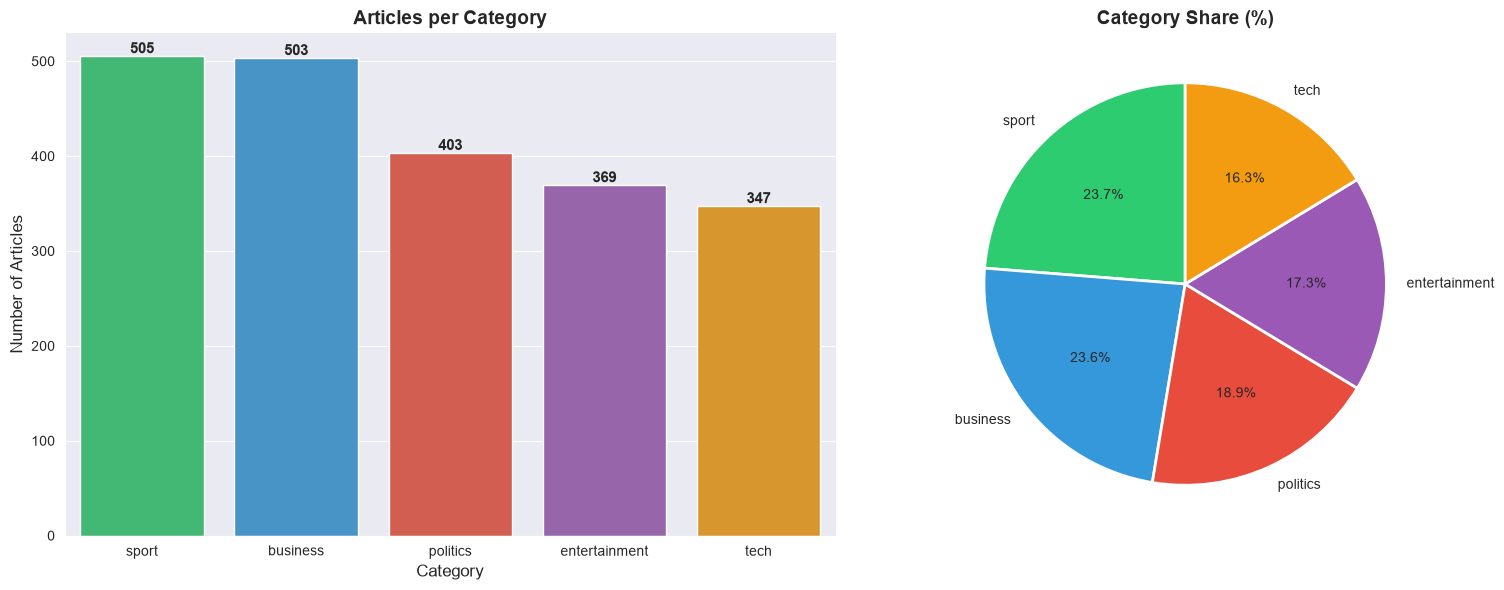

In [5]:
# ──────────────────────────────────────────────
# Consistent Color Palette (used across entire notebook)
# ──────────────────────────────────────────────
palette = {
    'business': '#3498db',
    'entertainment': '#9b59b6',
    'politics': '#e74c3c',
    'sport': '#2ecc71',
    'tech': '#f39c12'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ─── Plot 1: Bar Chart ───
ax1 = axes[0]
sns.countplot(
    x='category', data=df,
    order=class_counts.index,
    palette=palette,
    ax=ax1
)
# Add count labels on top of each bar
for bar in ax1.patches:
    ax1.annotate(
        f'{int(bar.get_height())}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )
ax1.set_title('Articles per Category', fontsize=14, fontweight='bold')
ax1.set_xlabel('Category', fontsize=12)
ax1.set_ylabel('Number of Articles', fontsize=12)

# ─── Plot 2: Pie Chart ───
ax2 = axes[1]
pie_colors = [palette[cat] for cat in class_counts.index]
ax2.pie(
    class_counts.values,
    labels=class_counts.index,
    colors=pie_colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax2.set_title('Category Share (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

WORD COUNT STATISTICS BY CATEGORY
                mean  median  min   max
category                               
tech           513.2   460.0  162  2969
politics       456.2   439.0   89  4432
entertainment  332.7   262.0  143  3482
sport          330.6   291.0  114  1662
business       328.7   297.0  140   891


/var/folders/0z/c_vy61yn3jq8782h_64v49mh0000gn/T/ipykernel_18520/1740673299.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


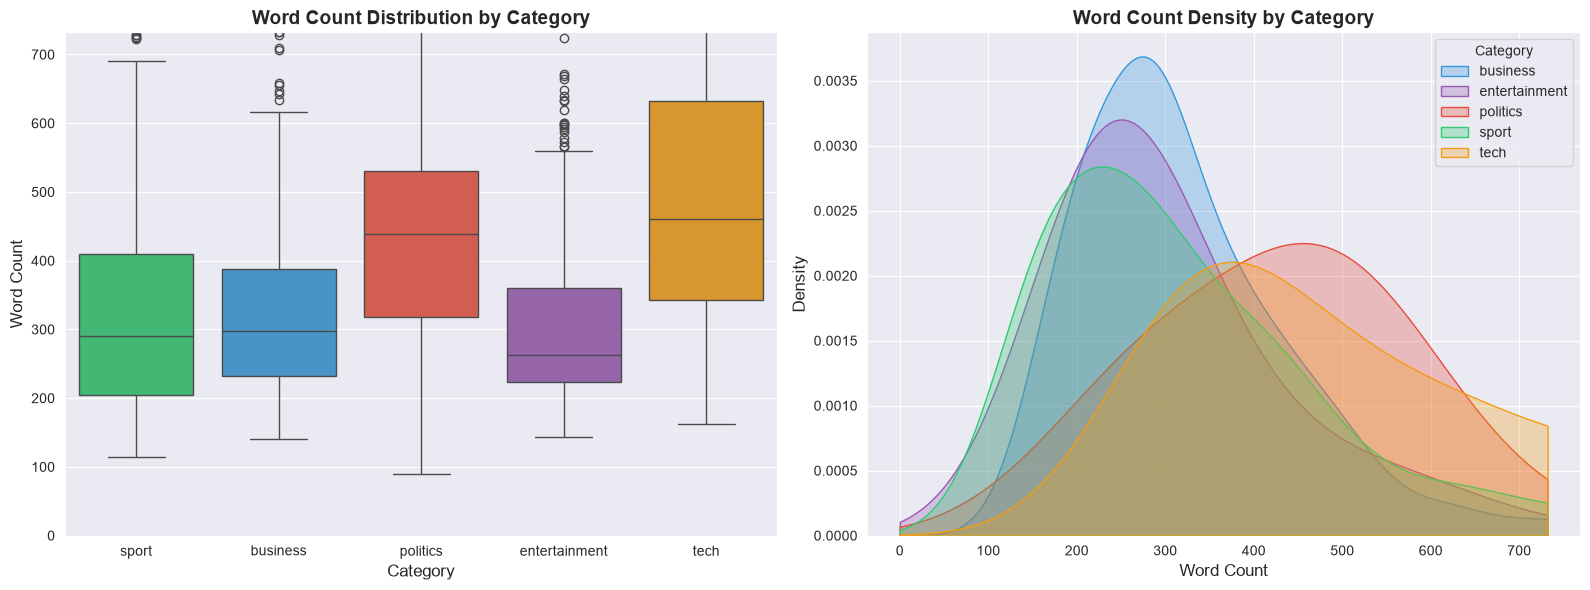

In [6]:
# ──────────────────────────────────────────────
# Article Length Analysis per Category
# ──────────────────────────────────────────────
print("=" * 50)
print("WORD COUNT STATISTICS BY CATEGORY")
print("=" * 50)
length_stats = (
    df.groupby('category')['word_count']
    .agg(['mean', 'median', 'min', 'max'])
    .round(1)
    .sort_values('mean', ascending=False)
)
print(length_stats)

# 95th percentile cap for cleaner visuals
word_count_p95 = df['word_count'].quantile(0.95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ─── Plot 1: Box Plot ───
ax1 = axes[0]
sns.boxplot(
    x='category', y='word_count', data=df,
    palette=palette,
    order=class_counts.index,
    ax=ax1
)
ax1.set_ylim(0, word_count_p95)
ax1.set_title('Word Count Distribution by Category', fontsize=14, fontweight='bold')
ax1.set_xlabel('Category', fontsize=12)
ax1.set_ylabel('Word Count', fontsize=12)

# ─── Plot 2: Overlapping KDE ───
ax2 = axes[1]
for category in sorted(df['category'].unique()):
    subset = df[df['category'] == category]['word_count']
    sns.kdeplot(
        subset,
        clip=(0, word_count_p95),
        fill=True,
        alpha=0.3,
        color=palette[category],
        label=category,
        ax=ax2
    )
ax2.set_title('Word Count Density by Category', fontsize=14, fontweight='bold')
ax2.set_xlabel('Word Count', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.legend(title='Category')

plt.tight_layout()
plt.savefig('outputs/02_word_count_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### 📝 Observations
- **Most / fewest articles:** *(fill in after reviewing the bar chart)*
- **Balance verdict:** *(fill in from the imbalance ratio output above)*
- **Longest articles:** *(fill in from the word-count stats table — which categories tend to be longest on average?)*

✅ Class distribution analysis complete!

## 🧹 Step 3: Text Preprocessing Pipeline
Raw text must be cleaned before it can be converted to numbers. Our pipeline applies these steps in order:

| Step | Action | Example |
|------|--------|---------|
| 1 | **Lowercase** | "Profits" → "profits" |
| 2 | **Remove URLs & emails** | "visit http://bbc.co.uk" → "visit" |
| 3 | **Remove numbers & punctuation** | "$1.13bn!" → "bn" |
| 4 | **Tokenize** | "profits rose" → ["profits", "rose"] |
| 5 | **Remove stopwords** | ["the", "firm", "is"] → ["firm"] |
| 6 | **Lemmatize (POS-aware)** | "running" → "run", "companies" → "company" |

### Why Lemmatization over Stemming?
Stemming crudely chops word endings (e.g. "studies" → "studi"), while lemmatization uses a dictionary to return a real root word (e.g. "studies" → "study"). WordNetLemmatizer defaults to treating every word as a noun, so we first tag each word’s part of speech (noun / verb / adjective / adverb) and pass that to the lemmatizer for accurate results.

In [7]:
# ──────────────────────────────────────────────
# NLTK Resources & Tool Initialization
# ──────────────────────────────────────────────
# Download POS tagger (resource name differs across NLTK versions)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# Initialize tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

print(f"Number of English stopwords: {len(stop_words)}")
print(f"Sample stopwords (first 15): {sorted(stop_words)[:15]}")

Number of English stopwords: 198
Sample stopwords (first 15): ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't"]


In [8]:
# ──────────────────────────────────────────────
# POS Tag Mapper: Penn Treebank → WordNet
# ──────────────────────────────────────────────
from nltk import pos_tag
from nltk.corpus import wordnet


def get_wordnet_pos(treebank_tag):
    """Map a Penn Treebank POS tag to the corresponding WordNet POS tag.

    This lets WordNetLemmatizer produce accurate lemmas by knowing
    whether a word is a noun, verb, adjective, or adverb.
    """
    if treebank_tag.startswith('J'):   # Adjective
        return wordnet.ADJ
    elif treebank_tag.startswith('V'): # Verb
        return wordnet.VERB
    elif treebank_tag.startswith('R'): # Adverb
        return wordnet.ADV
    else:                              # Default → Noun
        return wordnet.NOUN


print("\u2705 POS tag mapper defined.")

✅ POS tag mapper defined.


In [9]:
# ──────────────────────────────────────────────
# Main Preprocessing Function
# ──────────────────────────────────────────────

def preprocess_text(text):
    """
    Clean raw text and return a lemmatized string with stopwords
    removed. This exact function must be reused unchanged in the
    Streamlit app for consistent predictions.
    """
    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    # 3. Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # 4. Remove everything that is not a letter or whitespace
    #    (handles numbers AND punctuation in one step)
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 5. Collapse multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 6. Tokenize
    tokens = word_tokenize(text)

    # 7. Remove stopwords and tokens shorter than 3 characters
    tokens = [t for t in tokens if t not in stop_words and len(t) >= 3]

    # 8. POS-tag the remaining tokens
    tagged_tokens = pos_tag(tokens)

    # 9. Lemmatize each token with its POS tag
    lemmatized_tokens = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged_tokens
    ]

    # 10. Rejoin into a single string
    return ' '.join(lemmatized_tokens)


# ─── Quick Test ───
test = "The companies were running their profits up by 25% — visit https://bbc.co.uk!"
print("=" * 50)
print("PREPROCESSING TEST")
print("=" * 50)
print(f"Original : {test}")
print(f"Cleaned  : {preprocess_text(test)}")

PREPROCESSING TEST
Original : The companies were running their profits up by 25% — visit https://bbc.co.uk!
Cleaned  : company run profit visit


In [10]:
# ──────────────────────────────────────────────
# Apply Pipeline to Entire Dataset
# ──────────────────────────────────────────────
import time

print("⏳ Preprocessing all articles (this may take 1-2 minutes)...")
start_time = time.time()

df['text_clean'] = df['text'].apply(preprocess_text)

elapsed = time.time() - start_time
print(f"\u2705 Done in {elapsed:.1f} seconds")

# Add cleaned word count
df['clean_word_count'] = df['text_clean'].apply(lambda x: len(x.split()))

# Drop any rows where cleaned text is empty
empty_mask = df['text_clean'].str.strip().str.len() == 0
empty_count = empty_mask.sum()
df = df[~empty_mask].reset_index(drop=True)

print(f"Rows with empty cleaned text dropped: {empty_count}")
print(f"Final dataset shape: {df.shape}")

⏳ Preprocessing all articles (this may take 1-2 minutes)...
✅ Done in 42.3 seconds
Rows with empty cleaned text dropped: 0
Final dataset shape: (2127, 6)


In [11]:
# ──────────────────────────────────────────────
# Before vs After Comparison
# ──────────────────────────────────────────────
samples = df.sample(3, random_state=42)

print("=" * 50)
print("SAMPLE COMPARISONS (Before vs After)")
print("=" * 50)
for idx, row in samples.iterrows():
    print(f"\n\u25b6 Category: {row['category'].upper()}")
    print(f"  Original ({row['word_count']} words): {row['text'][:250]}...")
    print(f"  Cleaned  ({row['clean_word_count']} words): {row['text_clean'][:250]}...")
    print("-" * 50)

# Overall reduction
mean_before = df['word_count'].mean()
mean_after = df['clean_word_count'].mean()
pct_reduction = ((mean_before - mean_after) / mean_before) * 100

print("\n" + "=" * 50)
print("OVERALL WORD COUNT REDUCTION")
print("=" * 50)
print(f"Average words per article BEFORE: {mean_before:.1f}")
print(f"Average words per article AFTER:  {mean_after:.1f}")
print(f"Reduction: {pct_reduction:.1f}%")

# Vocabulary size comparison
vocab_before = set(' '.join(df['text'].str.lower()).split())
vocab_after = set(' '.join(df['text_clean']).split())
vocab_reduction = ((len(vocab_before) - len(vocab_after)) / len(vocab_before)) * 100

print("\n" + "=" * 50)
print("VOCABULARY SIZE")
print("=" * 50)
print(f"Unique words BEFORE: {len(vocab_before):,}")
print(f"Unique words AFTER:  {len(vocab_after):,}")
print(f"Reduction: {vocab_reduction:.1f}%")

SAMPLE COMPARISONS (Before vs After)

▶ Category: BUSINESS
  Original (251 words): EU 'too slow' on economic reforms

Most EU countries have failed to put in place policies aimed at making Europe the world's most competitive economy by the end of the decade, a report says.

The study, undertaken by the European Commission, sought t...
  Cleaned  (134 words): slow economic reform country fail put place policy aim make europe world competitive economy end decade report say study undertaken european commission seek assess far move towards meet economic target leader summit lisbon pledge european economy wou...
--------------------------------------------------

▶ Category: TECH
  Original (230 words): BBC web search aids odd queries

The BBC's online search engine was used a record amount in 2004, helping with enquires both simple and strange.

More than 277 million enquiries were made, asking for informaton of a wide range of subjects. The most r...
  Cleaned  (120 words): bbc web search

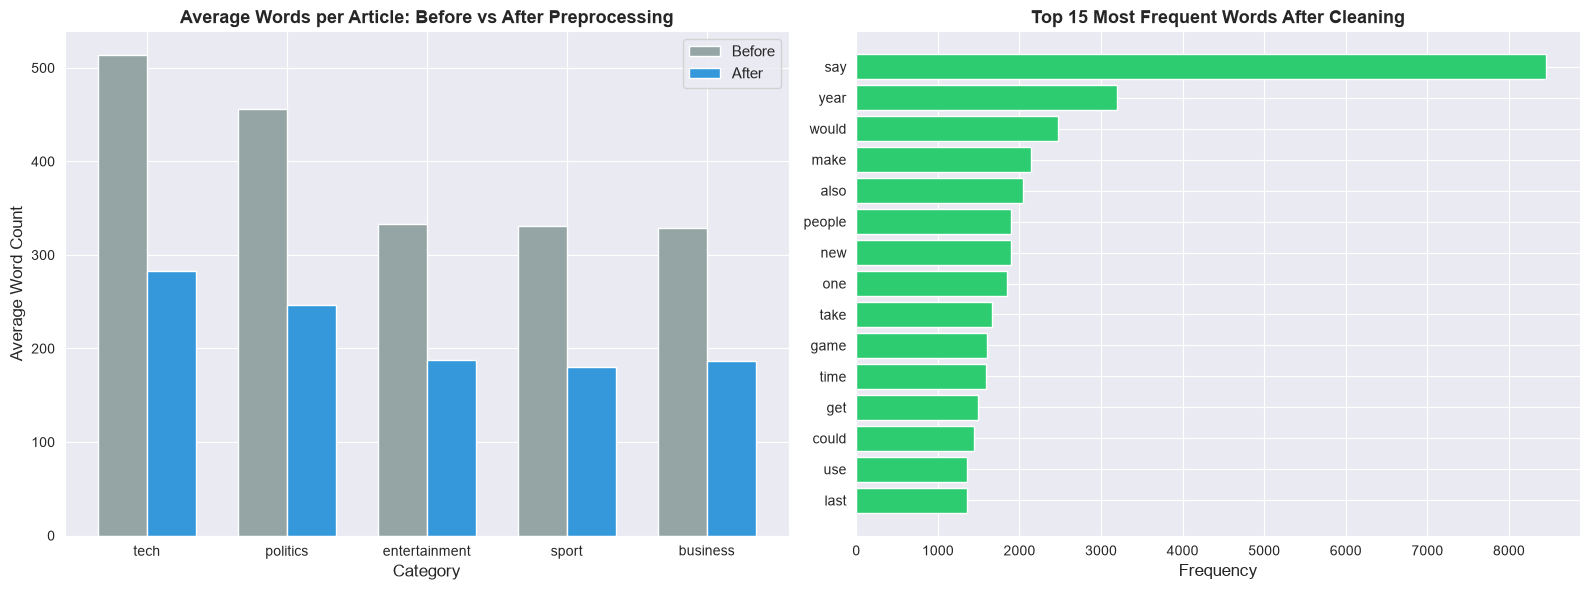

✅ Text preprocessing complete!


In [12]:
# ──────────────────────────────────────────────
# Preprocessing Effect Visualization
# ──────────────────────────────────────────────
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ─── Plot 1: Grouped Bar Chart (Before vs After) ───
ax1 = axes[0]
mean_by_cat = df.groupby('category')[['word_count', 'clean_word_count']].mean()
mean_by_cat = mean_by_cat.sort_values('word_count', ascending=False)

x = np.arange(len(mean_by_cat))
width = 0.35

bars_before = ax1.bar(x - width / 2, mean_by_cat['word_count'],
                      width, label='Before', color='#95a5a6')
bars_after = ax1.bar(x + width / 2, mean_by_cat['clean_word_count'],
                     width, label='After', color='#3498db')

ax1.set_xticks(x)
ax1.set_xticklabels(mean_by_cat.index)
ax1.set_title('Average Words per Article: Before vs After Preprocessing',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Category', fontsize=12)
ax1.set_ylabel('Average Word Count', fontsize=12)
ax1.legend(fontsize=11)

# ─── Plot 2: Top 15 Most Frequent Words After Cleaning ───
ax2 = axes[1]
word_freq = Counter(' '.join(df['text_clean']).split())
top_15 = word_freq.most_common(15)
words, counts = zip(*top_15)

# Plot in descending order (most frequent on top)
ax2.barh(range(len(words) - 1, -1, -1), counts, color='#2ecc71')
ax2.set_yticks(range(len(words) - 1, -1, -1))
ax2.set_yticklabels(words)
ax2.set_title('Top 15 Most Frequent Words After Cleaning',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Frequency', fontsize=12)

plt.tight_layout()
plt.savefig('outputs/03_preprocessing_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print("\u2705 Text preprocessing complete!")

## 🔢 Step 4: Train/Test Split & TF-IDF Feature Extraction

### What does TF-IDF measure?
**TF-IDF (Term Frequency – Inverse Document Frequency)** scores how important a word is to one document relative to the whole collection.

- **TF(t, d)** = (times term *t* appears in document *d*) / (total terms in *d*) — how frequent the word is *here*
- **IDF(t)** = log(N / df(t)) — how *rare* the word is across all N documents. Common words like “said” get a low IDF; specific words like “striker” or “inflation” get a high IDF.
- **TF-IDF = TF × IDF**

A high score means the word is frequent in this article but rare elsewhere, which makes it a strong signal of the article’s topic.

### Why we split BEFORE vectorizing
If the vectorizer is fitted on the full dataset, it learns vocabulary and IDF values from test articles too. That is **data leakage** and inflates the final scores. Correct order:
1. Split the data
2. `fit_transform` the vectorizer on the **training set only**
3. `transform` (never fit) the test set with the same vectorizer

In [13]:
# ──────────────────────────────────────────────
# Train/Test Split (80/20, Stratified)
# ──────────────────────────────────────────────
X = df['text_clean']
y = df['category']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keep class proportions identical in both sets
)

print("=" * 50)
print("TRAIN / TEST SPLIT")
print("=" * 50)
print(f"Training set size: {len(X_train_text)}")
print(f"Test set size:     {len(X_test_text)}")

# Verify stratification: class distribution should be nearly identical
train_pct = y_train.value_counts(normalize=True).mul(100).round(2)
test_pct = y_test.value_counts(normalize=True).mul(100).round(2)

strat_df = pd.DataFrame({
    'Train %': train_pct,
    'Test %': test_pct
}).sort_index()

print("\n" + "=" * 50)
print("STRATIFICATION CHECK (class %)")
print("=" * 50)
print(strat_df)

TRAIN / TEST SPLIT
Training set size: 1701
Test set size:     426

STRATIFICATION CHECK (class %)
               Train %  Test %
category                      
business         23.63   23.71
entertainment    17.34   17.37
politics         18.93   19.01
sport            23.75   23.71
tech             16.34   16.20


In [14]:
# ──────────────────────────────────────────────
# TF-IDF Vectorizer: Fit on Train, Transform Both
# ──────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=10000,    # keep the 10,000 most informative terms
    ngram_range=(1, 2),    # include both unigrams and bigrams
    min_df=2,              # ignore terms appearing in fewer than 2 docs
    max_df=0.95,           # ignore terms appearing in >95% of docs (near-universal words)
    sublinear_tf=True      # use 1 + log(tf) to dampen very frequent terms
)

# fit ONLY on training data to avoid data leakage
X_train = tfidf.fit_transform(X_train_text)
# transform test data using the same learned vocabulary & IDF weights
X_test = tfidf.transform(X_test_text)

# ─── Summary Statistics ───
print("=" * 50)
print("TF-IDF MATRIX")
print("=" * 50)
print(f"Train matrix shape: {X_train.shape}")
print(f"Test matrix shape:  {X_test.shape}")
print(f"Vocabulary size:    {len(tfidf.vocabulary_)}")
print(f"Non-zero elements in train matrix: {X_train.nnz:,}")

# Sparsity: percentage of zero entries in the matrix
sparsity = (1 - X_train.nnz / (X_train.shape[0] * X_train.shape[1])) * 100
print(f"Sparsity: {sparsity:.2f}%  (most entries are zero — sparse matrices save memory)")

# Sample feature names
feature_names = tfidf.get_feature_names_out()
print(f"\n20 sample features: {list(feature_names[::len(feature_names)//20][:20])}")

# Count bigrams (features containing a space)
num_bigrams = sum(1 for f in feature_names if ' ' in f)
print(f"Bigrams in vocabulary: {num_bigrams} / {len(feature_names)}")

TF-IDF MATRIX
Train matrix shape: (1701, 10000)
Test matrix shape:  (426, 10000)
Vocabulary size:    10000
Non-zero elements in train matrix: 255,064
Sparsity: 98.50%  (most entries are zero — sparse matrices save memory)

20 sample features: ['aaa', 'ash', 'breakfast', 'closure', 'customer say', 'due release', 'feel', 'generation dvd', 'hold', 'jens', 'location', 'mine', 'official spokesman', 'place last', 'rate increase', 'san jose', 'shoot', 'sullivan', 'tory leader', 'wander']
Bigrams in vocabulary: 3900 / 10000


In [15]:
# ──────────────────────────────────────────────
# Inspect TF-IDF Scores for One Article
# ──────────────────────────────────────────────

# Take the first training document
doc_idx = 0
doc_vector = X_train[doc_idx]

# Get non-zero TF-IDF values and their feature names
non_zero_indices = doc_vector.nonzero()[1]
non_zero_scores = doc_vector.toarray().ravel()[non_zero_indices]
non_zero_terms = feature_names[non_zero_indices]

# Build DataFrame and sort
doc_tfidf_df = pd.DataFrame({
    'Term': non_zero_terms,
    'TF-IDF': non_zero_scores
}).sort_values('TF-IDF', ascending=False)

print("=" * 50)
print("TOP 10 TF-IDF TERMS IN FIRST TRAINING DOCUMENT")
print("=" * 50)
print(doc_tfidf_df.head(10).to_string(index=False))

# Context for this article
first_doc_text = X_train_text.iloc[doc_idx]
first_doc_label = y_train.iloc[doc_idx]
print(f"\nCategory: {first_doc_label}")
print(f"Cleaned text (first 200 chars): {first_doc_text[:200]}...")

TOP 10 TF-IDF TERMS IN FIRST TRAINING DOCUMENT
       Term   TF-IDF
       rail 0.325228
   accident 0.223878
     derail 0.220571
    railway 0.215456
maintenance 0.207118
      leeds 0.179005
    section 0.177461
      trial 0.162023
    manager 0.145348
        die 0.137665

Category: politics
Cleaned text (first 200 chars): hatfield executive trial engineering firm balfour beatty five railway manager trial manslaughter hatfield rail crash four people die section rail break high speed train derail balfour beatty railway m...


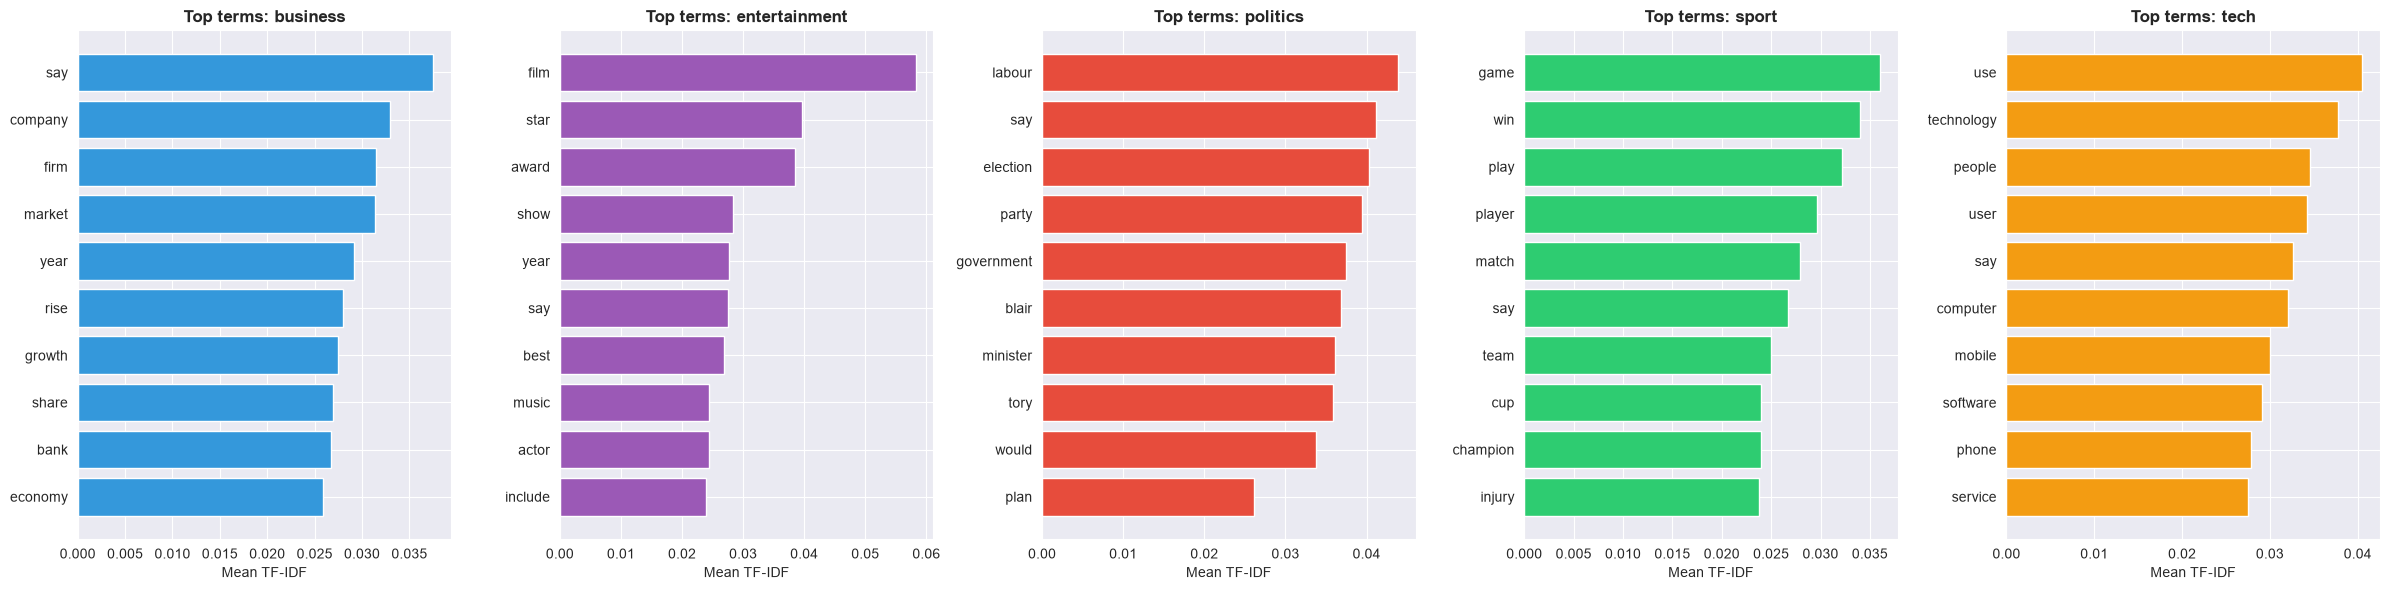

TOP 10 TF-IDF TERMS PER CATEGORY
business: say, company, firm, market, year, rise, growth, share, bank, economy
entertainment: film, star, award, show, year, say, best, music, actor, include
politics: labour, say, election, party, government, blair, minister, tory, would, plan
sport: game, win, play, player, match, say, team, cup, champion, injury
tech: use, technology, people, user, say, computer, mobile, software, phone, service


In [16]:
# ──────────────────────────────────────────────
# Top TF-IDF Terms per Category
# ──────────────────────────────────────────────
y_train_arr = y_train.values
categories_sorted = sorted(df['category'].unique())

# Compute top-10 terms per category
top_terms_per_cat = {}
for cat in categories_sorted:
    mask = y_train_arr == cat
    mean_tfidf = np.asarray(X_train[mask].mean(axis=0)).ravel()
    top_indices = mean_tfidf.argsort()[-10:][::-1]
    top_terms_per_cat[cat] = [
        (feature_names[i], mean_tfidf[i]) for i in top_indices
    ]

# ─── Visualization: 5 horizontal bar subplots ───
fig, axes = plt.subplots(1, 5, figsize=(24, 6))

for ax, cat in zip(axes, categories_sorted):
    terms, scores = zip(*top_terms_per_cat[cat])
    # Plot with highest score on top
    y_pos = range(len(terms) - 1, -1, -1)
    ax.barh(y_pos, scores, color=palette[cat])
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(terms, fontsize=10)
    ax.set_title(f'Top terms: {cat}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean TF-IDF', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/04_top_tfidf_terms.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Plain-text summary ───
print("=" * 50)
print("TOP 10 TF-IDF TERMS PER CATEGORY")
print("=" * 50)
for cat in categories_sorted:
    terms_list = [t for t, _ in top_terms_per_cat[cat]]
    print(f"{cat}: {', '.join(terms_list)}")

### 📝 Observations
- **Do the top terms make intuitive sense?** *(fill in after reviewing the chart)*
- **Which categories share vocabulary?** *(possible confusion for the classifier later)*
- **Why are bigrams useful here?** *(fill in — e.g. "prime minister" vs just "prime" or "minister")*

✅ TF-IDF feature extraction complete! Ready for modelling.